## 1. Import libraries & packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## 2. Load training data source into a dataframe & perform basic data checks

In [2]:
df = pd.read_csv("data/raw/train.csv")
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


#### 2.1 Shape of dataset

In [3]:
print(f"No. of rows: {df.shape[0]}")
print(f"No. of columns: {df.shape[1]}")

No. of rows: 439140
No. of columns: 16


#### 2.2 Schema of dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

#### 2.3 Check for Null values

In [5]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

#### 2.4 Check for duplicate rows

In [6]:
print(f"No of duplicate rows: {df.duplicated().sum()}")

No of duplicate rows: 0


In [7]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


# 3. Class imbalance check

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


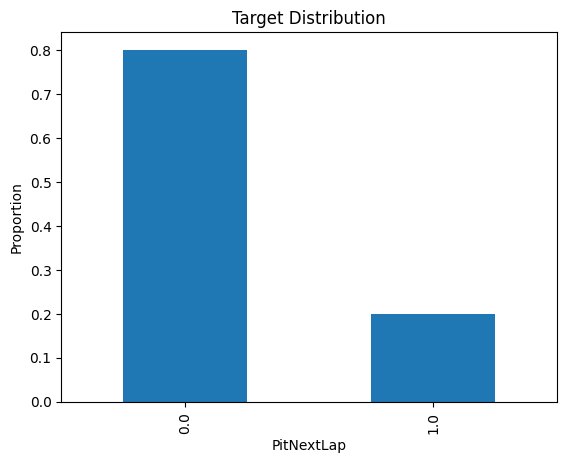

In [8]:
balance = df['PitNextLap'].value_counts(normalize=True)
print(balance)

# Visualize it
balance.plot(kind='bar', title='Target Distribution')
plt.ylabel('Proportion')
plt.show()

# 4. Identifying Numerical & Nominal attributes

Since some columns are nominal in nature but are forced to be numerical due to their datatypes, therefore appending those columns to this list before plotting

In [26]:
categorial_cols = []
numerical_cols = []

all_columns = df.columns.to_list()
for cols in all_columns:

    # check for object, category and bool datatype
    if (
        (df[cols].dtype == "object"
        or str(df[cols].dtype) == "category"
        or df[cols].dtype == "bool") and (df[cols].nunique() <= 5)
    ):
        categorial_cols.append(cols)
    
    # left over true numerical cols
    else:
        numerical_cols.append(cols)

print(categorial_cols)
print(numerical_cols)

[]
['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [21]:
type(df['Race'])

pandas.Series

# 5. Univariate Analysis

#### 5.1 Plot the count distribution of categorical columns